1. Imports

In [1]:
import os
import glob
import numpy as np
import rasterio
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
DATASET_PATH = "/content/drive/MyDrive/datasets/SmallMinesDS"

Verify dataset structure

In [4]:
for root, dirs, files in os.walk(DATASET_PATH):
    print(root)
    print("dirs:", dirs)
    print("sample files:", files[:2])
    print("-"*50)

/content/drive/MyDrive/datasets/SmallMinesDS
dirs: ['2016', '2022']
sample files: []
--------------------------------------------------
/content/drive/MyDrive/datasets/SmallMinesDS/2016
dirs: ['IMAGE', 'MASK']
sample files: []
--------------------------------------------------
/content/drive/MyDrive/datasets/SmallMinesDS/2016/IMAGE
dirs: []
sample files: ['IMG_GH_0282_2016.tif', 'IMG_GH_0299_2016.tif']
--------------------------------------------------
/content/drive/MyDrive/datasets/SmallMinesDS/2016/MASK
dirs: []
sample files: ['MASK_GH_0365_2016.tif', 'MASK_GH_0306_2016.tif']
--------------------------------------------------
/content/drive/MyDrive/datasets/SmallMinesDS/2022
dirs: ['MASK', 'IMAGE']
sample files: []
--------------------------------------------------
/content/drive/MyDrive/datasets/SmallMinesDS/2022/MASK
dirs: []
sample files: ['MASK_GH_0331_2022.tif', 'MASK_GH_0510_2022.tif']
--------------------------------------------------
/content/drive/MyDrive/datasets/SmallMine

Collect IMAGE and MASK paths

In [5]:
image_paths = glob.glob(DATASET_PATH + "/**/IMAGE/*.tif", recursive=True)
mask_paths  = glob.glob(DATASET_PATH + "/**/MASK/*.tif", recursive=True)

print("Images:", len(image_paths))
print("Masks:", len(mask_paths))

Images: 4270
Masks: 4270


Pair IMAGE - MASK correctly

In [7]:
def get_id(path):
    # Remove the directory and prefixes 'IMG_' or 'MASK_'
    filename = os.path.basename(path)
    return filename.replace("IMG_", "").replace("MASK_", "").replace(".tif", "")

image_dict = {get_id(p): p for p in image_paths}
mask_dict  = {get_id(p): p for p in mask_paths}

pairs = []

for id_ in image_dict:
    if id_ in mask_dict:
        pairs.append((image_dict[id_], mask_dict[id_]))

print(f"Images found: {len(image_dict)}")
print(f"Masks found: {len(mask_dict)}")
print(f"Paired samples: {len(pairs)}")

# Sanity check: show the first pair
if pairs:
    print("\nExample pair:")
    print(f"Image: {pairs[0][0]}")
    print(f"Mask:  {pairs[0][1]}")

Images found: 4270
Masks found: 4270
Paired samples: 4270

Example pair:
Image: /content/drive/MyDrive/datasets/SmallMinesDS/2016/IMAGE/IMG_GH_0282_2016.tif
Mask:  /content/drive/MyDrive/datasets/SmallMinesDS/2016/MASK/MASK_GH_0282_2016.tif


In [11]:
class SmallMinesDataset(Dataset):
    def __init__(self, pairs, transform=None):
        self.pairs = pairs
        self.transform = transform

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img_path, mask_path = self.pairs[idx]

        # Use rasterio to read multi-band or single-band TIFs
        with rasterio.open(img_path) as src:
            image = src.read().astype(np.float32)
            # Min-Max Normalization to [0, 1]
            img_min, img_max = image.min(), image.max()
            if img_max > img_min:
                image = (image - img_min) / (img_max - img_min)

        with rasterio.open(mask_path) as src:
            mask = src.read(1).astype(np.float32)
            # Ensure mask is binary (0 and 1)
            mask = (mask > 0).astype(np.float32)

        # Convert to torch tensors
        image = torch.from_numpy(image)
        mask = torch.from_numpy(mask).unsqueeze(0)  # Add channel dim: (1, H, W)

        if self.transform:
            # Add custom transformations here if needed
            pass

        return image, mask

# Re-split and re-instantiate to apply changes
train_pairs, val_pairs = train_test_split(pairs, test_size=0.2, random_state=42)
train_dataset = SmallMinesDataset(train_pairs)
val_dataset = SmallMinesDataset(val_pairs)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=2)

print(f"Updated Dataset and DataLoaders. Training samples: {len(train_dataset)}")

Updated Dataset and DataLoaders. Training samples: 3416


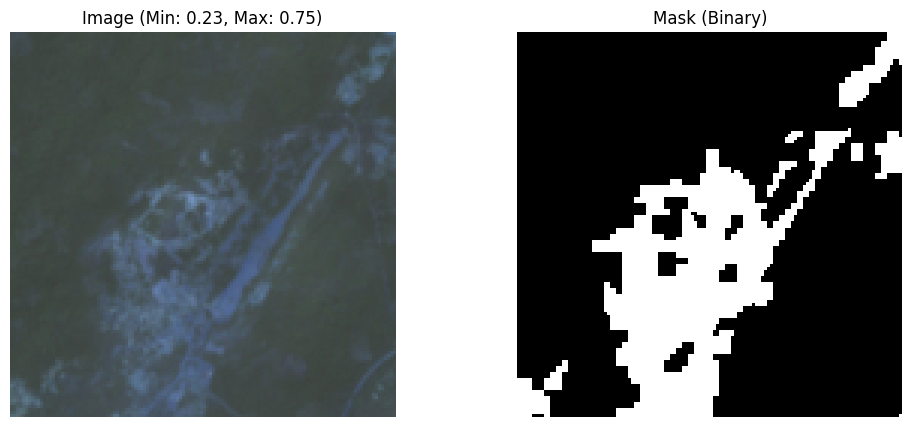

In [13]:
import matplotlib.pyplot as plt

def visualize_sample(dataset, idx=0):
    image, mask = dataset[idx]

    # image is (C, H, W), convert to (H, W, C)
    img_np = image.permute(1, 2, 0).cpu().numpy()

    # If multi-band, take first 3 for RGB visualization
    if img_np.shape[2] > 3:
        img_np = img_np[:, :, :3]
    elif img_np.shape[2] == 1:
        img_np = img_np.squeeze()

    mask_np = mask.squeeze().cpu().numpy()

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.title(f"Image (Min: {img_np.min():.2f}, Max: {img_np.max():.2f})")
    plt.imshow(img_np)
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.title("Mask (Binary)")
    plt.imshow(mask_np, cmap='gray')
    plt.axis('off')
    plt.show()

# Visualize a sample to confirm normalization fix
visualize_sample(train_dataset, idx=0)

In [10]:
batch_size = 16

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

print(f"Created DataLoaders with batch size: {batch_size}")

Created DataLoaders with batch size: 16


### Export Pipeline Results
Since this notebook serves as the data pipeline, we will save the finalized pairs to a CSV. This allows any other notebook to skip the globbing and pairing logic.

In [14]:
import pandas as pd

# Create a DataFrame from the pairs
pairs_df = pd.DataFrame(pairs, columns=['image_path', 'mask_path'])

# Save to Google Drive
csv_output_path = os.path.join(DATASET_PATH, 'paired_dataset.csv')
pairs_df.to_csv(csv_output_path, index=False)

print(f"Pipeline complete! Paired dataset saved to: {csv_output_path}")
display(pairs_df.head())

Pipeline complete! Paired dataset saved to: /content/drive/MyDrive/datasets/SmallMinesDS/paired_dataset.csv


,image_path,mask_path
0,/content/drive/MyDrive/datasets/SmallMinesDS/2...,/content/drive/MyDrive/datasets/SmallMinesDS/2...
1,/content/drive/MyDrive/datasets/SmallMinesDS/2...,/content/drive/MyDrive/datasets/SmallMinesDS/2...
2,/content/drive/MyDrive/datasets/SmallMinesDS/2...,/content/drive/MyDrive/datasets/SmallMinesDS/2...
3,/content/drive/MyDrive/datasets/SmallMinesDS/2...,/content/drive/MyDrive/datasets/SmallMinesDS/2...
4,/content/drive/MyDrive/datasets/SmallMinesDS/2...,/content/drive/MyDrive/datasets/SmallMinesDS/2...
